In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

2026-03-06 18:31:48.912147: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772821909.158486      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772821909.218300      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772821909.752518      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772821909.752576      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772821909.752578      55 computation_placer.cc:177] computation placer alr

In [2]:
from pathlib import Path

ICH_ROOT = Path("/kaggle/input/datasets/vbookshelf/computed-tomography-ct-images/computed-tomography-images-for-intracranial-hemorrhage-detection-and-segmentation-1.0.0")

ISCH_ROOT = Path("/kaggle/input/datasets/orvile/cpaisd-acute-ischemic-stroke-dataset/dataset")

In [3]:
import pandas as pd

diagnosis = pd.read_csv(ICH_ROOT / "hemorrhage_diagnosis.csv")

print(diagnosis.head())
print(diagnosis.columns)

   PatientNumber  SliceNumber  Intraventricular  Intraparenchymal  \
0             49            1                 0                 0   
1             49            2                 0                 0   
2             49            3                 0                 0   
3             49            4                 0                 0   
4             49            5                 0                 0   

   Subarachnoid  Epidural  Subdural  No_Hemorrhage  Fracture_Yes_No  
0             0         0         0              1                0  
1             0         0         0              1                0  
2             0         0         0              1                0  
3             0         0         0              1                0  
4             0         0         0              1                0  
Index(['PatientNumber', 'SliceNumber', 'Intraventricular', 'Intraparenchymal',
       'Subarachnoid', 'Epidural', 'Subdural', 'No_Hemorrhage',
       'Fracture_Yes_N

In [4]:
def get_label(row):

    if row["No_Hemorrhage"] == 1:
        return "Normal"

    else:
        return "Hemorrhagic"

In [5]:
import pandas as pd

diagnosis = pd.read_csv(ICH_ROOT / "hemorrhage_diagnosis.csv")

# create label
diagnosis["label"] = diagnosis["No_Hemorrhage"].apply(lambda x: "normal" if x == 1 else "hemorrhage")

print(diagnosis["label"].value_counts())

label
normal        2183
hemorrhage     318
Name: count, dtype: int64


In [6]:
def get_class(row):
    
    if row["No_Hemorrhage"] == 1:
        return "normal"
    
    if row["Epidural"] == 1:
        return "epidural"
    
    if row["Subdural"] == 1:
        return "subdural"
    
    if row["Subarachnoid"] == 1:
        return "subarachnoid"
    
    if row["Intraventricular"] == 1:
        return "intraventricular"
    
    if row["Intraparenchymal"] == 1:
        return "intraparenchymal"

diagnosis["label"] = diagnosis.apply(get_class, axis=1)

print(diagnosis["label"].value_counts())

label
normal              2183
epidural             173
subdural              56
intraparenchymal      52
intraventricular      21
subarachnoid          16
Name: count, dtype: int64


In [7]:
from pathlib import Path
import os

# المسار الصحيح في كاجل
ICH_ROOT = Path("/kaggle/input/datasets/vbookshelf/computed-tomography-ct-images/computed-tomography-images-for-intracranial-hemorrhage-detection-and-segmentation-1.0.0")

image_paths = []

for _, row in diagnosis.iterrows():
    # رقم المريض محتاج padding (049)
    patient = str(row["PatientNumber"]).zfill(3)
    
    # رقم السلايس زي ما هو (1)
    slice_num = str(row["SliceNumber"])

    # المسار الجديد فيه كلمة "brain" في النص
    img_path = ICH_ROOT / "Patients_CT" / patient / "brain" / f"{slice_num}.jpg"

    # نتأكد إنه موجود فعلاً
    if img_path.exists():
        image_paths.append(str(img_path))
    else:
        image_paths.append(None)

diagnosis["image_path"] = image_paths

# تصفية الداتا اللي ملهاش صور (لو فيه)
df_hem = diagnosis[diagnosis["image_path"].notnull()].copy()

print(f"✅ تم إيجاد {len(df_hem)} صورة بنجاح!")
print(df_hem[["image_path", "label"]].head())

✅ تم إيجاد 2501 صورة بنجاح!
                                          image_path   label
0  /kaggle/input/datasets/vbookshelf/computed-tom...  normal
1  /kaggle/input/datasets/vbookshelf/computed-tom...  normal
2  /kaggle/input/datasets/vbookshelf/computed-tom...  normal
3  /kaggle/input/datasets/vbookshelf/computed-tom...  normal
4  /kaggle/input/datasets/vbookshelf/computed-tom...  normal


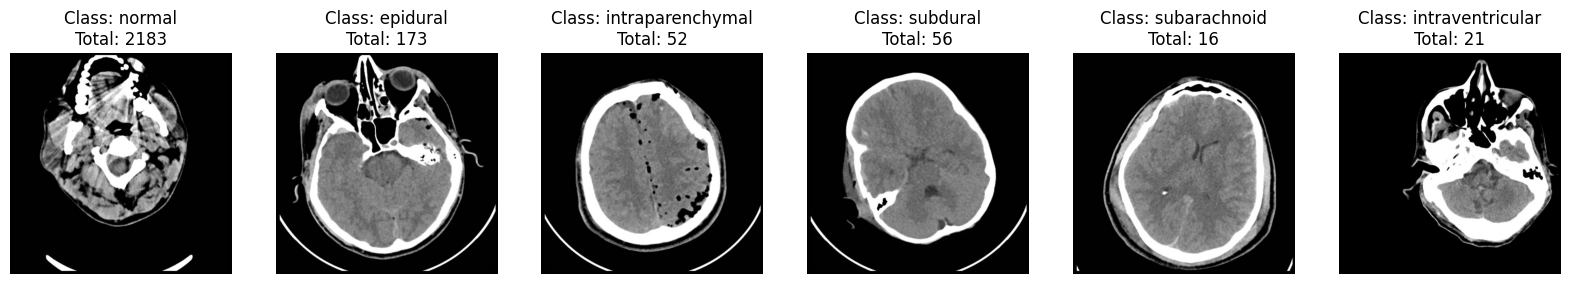

In [8]:
import matplotlib.pyplot as plt
import cv2

def plot_samples(df, n=5):
    plt.figure(figsize=(20, 10))
    classes = df['label'].unique()
    
    for i, cls in enumerate(classes):
        # بناخد أول صورة متاحة لكل Class
        sample = df[df['label'] == cls].iloc[0]
        img = cv2.imread(sample['image_path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(1, len(classes), i + 1)
        plt.imshow(img)
        plt.title(f"Class: {cls}\nTotal: {len(df[df['label']==cls])}")
        plt.axis('off')
    plt.show()

plot_samples(df_hem)

In [9]:
df_hem = diagnosis[["image_path", "label"]].copy()

print(df_hem.head())
print(df_hem.label.value_counts())

                                          image_path   label
0  /kaggle/input/datasets/vbookshelf/computed-tom...  normal
1  /kaggle/input/datasets/vbookshelf/computed-tom...  normal
2  /kaggle/input/datasets/vbookshelf/computed-tom...  normal
3  /kaggle/input/datasets/vbookshelf/computed-tom...  normal
4  /kaggle/input/datasets/vbookshelf/computed-tom...  normal
label
normal              2183
epidural             173
subdural              56
intraparenchymal      52
intraventricular      21
subarachnoid          16
Name: count, dtype: int64


In [10]:
df_hem = diagnosis[["image_path","label"]].copy()

df_hem = df_hem[df_hem["image_path"].notnull()]

print("Total images:",len(df_hem))

print(df_hem.label.value_counts())

Total images: 2501
label
normal              2183
epidural             173
subdural              56
intraparenchymal      52
intraventricular      21
subarachnoid          16
Name: count, dtype: int64


In [33]:
import os
import pandas as pd

# 1. تجميع صور الـ Ischemic (الجلطات)
# تأكد من المسار ده في الكاجل عندك
isch_path = "/kaggle/input/datasets/orvile/cpaisd-acute-ischemic-stroke-dataset/dataset" 
isch_images = [os.path.join(isch_path, f) for f in os.listdir(isch_path) if f.endswith('.jpg')]

df_isch = pd.DataFrame({
    'image_path': isch_images,
    'label': 'Ischemic',
    'label_id': 2
})

# 2. الدمج النهائي (سليم + نزيف + جلطة)
df_final = pd.concat([df_hem, df_isch], ignore_index=True)

# 3. إعادة التقسيم والـ Generators
train_df, test_df = train_test_split(df_final, test_size=0.2, stratify=df_final['label_id'])

# تأكد من تحويل label_id لـ string للـ Generator
train_df['label_id'] = train_df['label_id'].astype(str)
test_df['label_id'] = test_df['label_id'].astype(str)



In [75]:
import os
import numpy as np
import cv2
import glob
from tqdm import tqdm
import pandas as pd

# 1. تحديد المسار الرئيسي للداتا سيت على كاجل
base_path = "/kaggle/input/datasets/orvile/cpaisd-acute-ischemic-stroke-dataset/dataset"

# 2. البحث عن كل ملفات الـ npz في أي مكان جوه الداتا سيت
# استخدمنا ** لضمان البحث في كل المجلدات الفرعية
all_npz = glob.glob(os.path.join(base_path, "**/*.npz"), recursive=True)

# تصفية الملفات عشان ناخد image.npz بس ونبعد عن mask.npz
npz_files = [f for f in all_npz if "image.npz" in f]

print(f"🔍 تم العثور على {len(npz_files)} ملف image.npz")

# 3. استخراج الصور (نفس الكود السابق مع تعديل المسار)
output_dir = "/kaggle/working/ischemic_images"
os.makedirs(output_dir, exist_ok=True)
isch_paths = []

if len(npz_files) > 0:
    for i, file_path in enumerate(tqdm(npz_files)):
        try:
            data = np.load(file_path)
            # استخراج أول مصفوفة موجودة في الملف
            img_array = data[data.files[0]]
            
            # معالجة الصور 3D لو وجدت
            if len(img_array.shape) == 3:
                img_array = img_array[img_array.shape[0] // 2]
            
            # تحويل المدى (Normalization) ليكون من 0 لـ 255
            img_min, img_max = img_array.min(), img_array.max()
            if img_max > img_min:
                img_rescaled = ((img_array - img_min) / (img_max - img_min) * 255).astype(np.uint8)
            else:
                img_rescaled = np.zeros(img_array.shape, dtype=np.uint8)
            
            img_name = f"isch_{i}.jpg"
            save_path = os.path.join(output_dir, img_name)
            cv2.imwrite(save_path, img_rescaled)
            isch_paths.append(save_path)
        except:
            continue
    print(f"✅ تم استخراج {len(isch_paths)} صورة بنجاح!")
else:
    print("❌ لسه مش لاقي الملفات. جرب تطبع os.listdir('/kaggle/input/cpaisd-acute-ischemic-stroke-dataset') عشان نتأكد من الاسم")

🔍 تم العثور على 10165 ملف image.npz


100%|██████████| 10165/10165 [01:43<00:00, 98.45it/s]

✅ تم استخراج 10165 صورة بنجاح!


In [39]:
# 1. تحويل مسارات الصور المستخرجة لـ DataFrame
df_isch = pd.DataFrame({
    'image_path': isch_paths,
    'label': 'Ischemic',
    'label_id': 2
})

# 2. (اختياري) ممكن ناخد عينة فقط لو مش عايز تدرب على الـ 10 آلاف كلهم 
# عشان الوقت، هناخد مثلاً 3000 صورة عشوائية من الجلطات
df_isch_sampled = df_isch.sample(n=min(3000, len(df_isch)), random_state=42)

# 3. الدمج النهائي
df_final = pd.concat([df_hem, df_isch_sampled], ignore_index=True)

print("التوزيع النهائي للفئات:")
print(df_final['label'].value_counts())

التوزيع النهائي للفئات:
label
Ischemic            3000
normal              2183
epidural             173
subdural              56
intraparenchymal      52
intraventricular      21
subarachnoid          16
Name: count, dtype: int64


In [76]:
# تحويل كل أنواع النزيف إلى Hemorrhage
df_hem["label"] = df_hem["label"].apply(
    lambda x: "Hemorrhage" if x != "normal" else "Normal"
)

print(df_hem["label"].value_counts())

label
Normal        2183
Hemorrhage     318
Name: count, dtype: int64


In [77]:
label_map = {
    "Normal":0,
    "Hemorrhage":1,
    "Ischemic":2
}

df_hem["label_id"] = df_hem["label"].map(label_map)

In [78]:
df_isch = pd.DataFrame({
    "image_path": isch_paths,
    "label":"Ischemic"
})

df_isch["label_id"] = 2

In [79]:
df_final = pd.concat([df_hem, df_isch_sampled], ignore_index=True)

print(df_final["label"].value_counts())

label
Ischemic      3000
Normal        2183
Hemorrhage     318
Name: count, dtype: int64


In [81]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df_final,
    test_size=0.2,
    stratify=df_final["label"],
    random_state=42
)

In [82]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col="image_path",
    y_col="label",
    target_size=(224,224),
    class_mode="categorical",
    batch_size=32
)

test_gen = test_datagen.flow_from_dataframe(
    test_df,
    x_col="image_path",
    y_col="label",
    target_size=(224,224),
    class_mode="categorical",
    batch_size=32,
    shuffle=False
)

Found 4400 validated image filenames belonging to 3 classes.
Found 1101 validated image filenames belonging to 3 classes.


In [83]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

weights = compute_class_weight(
    "balanced",
    classes=np.unique(train_df["label_id"]),
    y=train_df["label_id"]
)

class_weights = dict(enumerate(weights))
print(class_weights)

{0: np.float64(0.8400152730049637), 1: np.float64(5.774278215223097), 2: np.float64(0.6111111111111112)}


In [108]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True,
    brightness_range=[0.8,1.2]
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

In [118]:
df_hemo = df_final[df_final["label"]=="Hemorrhage"]

df_hemo_aug = df_hemo.sample(1000, replace=True)

df_final = pd.concat([df_final, df_hemo_aug])

In [119]:
# نفترض df_final هو الداتا كلها
all_df = df_final.copy()

from sklearn.model_selection import train_test_split

# تقسيم الداتا: 80% Train، 10% Val، 10% Test
train_df, temp_df = train_test_split(
    all_df,
    test_size=0.2,
    stratify=all_df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 5200
Validation: 650
Test: 651


In [120]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="label",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=True
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="label",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

test_generator = val_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="label",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 5200 validated image filenames belonging to 3 classes.
Found 650 validated image filenames belonging to 3 classes.
Found 651 validated image filenames belonging to 3 classes.


In [121]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

Found 5200 validated image filenames belonging to 3 classes.


In [122]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

val_datagen = ImageDataGenerator(rescale=1./255)

In [123]:
val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="label",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 650 validated image filenames belonging to 3 classes.


In [124]:
print(val_df.head())
print(val_df["label"].value_counts())

                                             image_path       label  label_id
143   /kaggle/input/datasets/vbookshelf/computed-tom...  Hemorrhage         1
1172  /kaggle/input/datasets/vbookshelf/computed-tom...  Hemorrhage         1
1028  /kaggle/input/datasets/vbookshelf/computed-tom...      Normal         0
2386  /kaggle/input/datasets/vbookshelf/computed-tom...      Normal         0
5286      /kaggle/working/ischemic_images/isch_7662.jpg    Ischemic         2
label
Ischemic      300
Normal        218
Hemorrhage    132
Name: count, dtype: int64


In [125]:
print(val_generator.class_indices)

{'Hemorrhage': 0, 'Ischemic': 1, 'Normal': 2}


In [126]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import numpy as np
from sklearn.metrics import classification_report

tf.keras.backend.clear_session()

IMG_SIZE = 224
NUM_CLASSES = 3

# =========================
# ResNet50 Backbone
# =========================

base_model = tf.keras.applications.ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

# =========================
# Improved Focal Loss
# =========================

def categorical_focal_loss(gamma=2.0, alpha=0.75):

    def focal_loss(y_true, y_pred):

        y_true = tf.cast(y_true, tf.float32)

        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        cross_entropy = -y_true * tf.math.log(y_pred)

        loss = alpha * tf.pow(1 - y_pred, gamma) * cross_entropy

        return tf.reduce_sum(loss, axis=-1)

    return focal_loss


# =========================
# Compile Phase 1
# =========================

model.compile(

    optimizer=Adam(learning_rate=1e-4),

    loss=categorical_focal_loss(),

    metrics=['accuracy']

)

model.summary()

# =========================
# Callbacks
# =========================

checkpoint = ModelCheckpoint(
    "best_resnet_phase1.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

callbacks = [

    EarlyStopping(patience=5, restore_best_weights=True),

    ReduceLROnPlateau(patience=3),

    checkpoint

]

# =========================
# Phase 1 Training
# =========================

print("===== Phase 1: Feature Extraction =====")

history1 = model.fit(

    train_generator,

    validation_data=val_generator,

    epochs=10,

    class_weight=class_weights,

    callbacks=callbacks

)

# =========================
# Phase 2 Fine-Tuning
# =========================

print("===== Phase 2: Fine Tuning =====")

model.load_weights("best_resnet_phase1.keras")

base_model.trainable = True

# فتح آخر 30 طبقة فقط
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(

    optimizer=Adam(learning_rate=1e-6),

    loss=categorical_focal_loss(),

    metrics=['accuracy']

)

history2 = model.fit(

    train_generator,

    validation_data=val_generator,

    epochs=10,

    class_weight=class_weights,

    callbacks=[

        EarlyStopping(patience=5, restore_best_weights=True),

        ReduceLROnPlateau(patience=3)

    ]

)

# =========================
# Evaluation
# =========================

print("===== Final Evaluation =====")

pred = model.predict(test_generator)

pred_classes = np.argmax(pred, axis=1)

true_classes = test_generator.classes

print(classification_report(true_classes, pred_classes))

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,593,859 (90.00 MB)

 Trainable params: 6,147 (24.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

===== Phase 1: Feature Extraction =====


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 91s 498ms/step - accuracy: 0.4220 - loss: 0.9285 - val_accuracy: 0.5138 - val_loss: 0.3230 - learning_rate: 1.0000e-04
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 72s 439ms/step - accuracy: 0.5277 - loss: 0.4975 - val_accuracy: 0.7000 - val_loss: 0.1939 - learning_rate: 1.0000e-04
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 73s 447ms/step - accuracy: 0.5985 - loss: 0.3414 - val_accuracy: 0.7662 - val_loss: 0.1388 - learning_rate: 1.0000e-04
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 72s 442ms/step - accuracy: 0.6487 - loss: 0.2831 - val_accuracy: 0.7938 - val_loss: 0.1153 - learning_rate: 1.0000e-04
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 72s 439ms/step - accuracy: 0.7078 - loss: 0.2057 - val_accuracy: 0.8215 - val_loss: 0.0994 - learning_rate: 1.0000e-04
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 70s 430ms/step - accuracy: 0.7198 - loss: 0.1872 - val_accuracy: 0.8215 - val_loss: 0.0902 - learning_rate: 1.0000e-04
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 72s 44

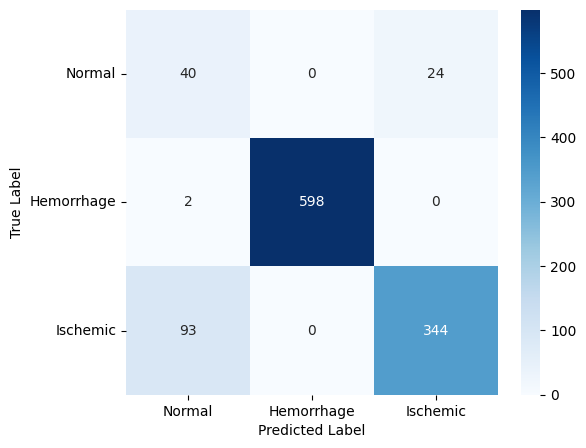

In [132]:
cm = confusion_matrix(true_classes, pred_classes)
labels = ["Normal", "Hemorrhage", "Ischemic"]
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.show()

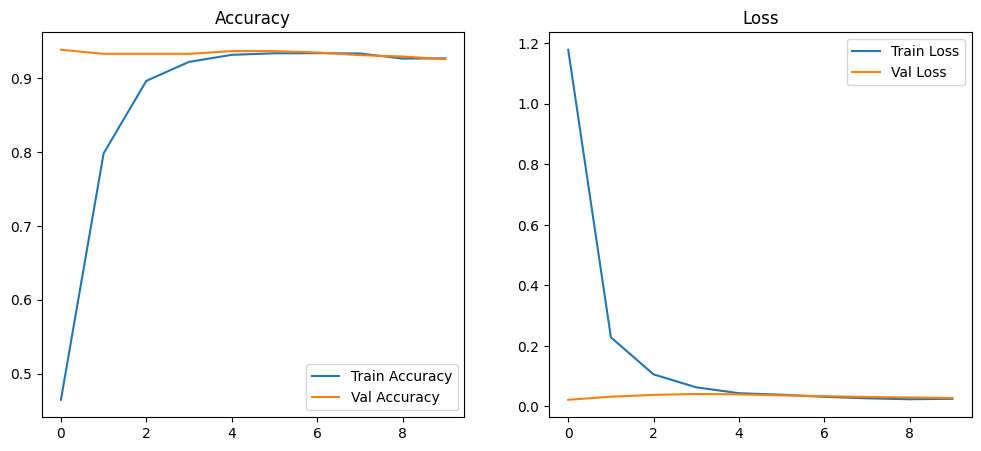

In [128]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

# **EfficientNetB0**

In [135]:
print(train_generator.class_indices) 

{'Hemorrhage': 0, 'Ischemic': 1, 'Normal': 2}


In [136]:
print(train_df["label"].value_counts())

label
Ischemic      2400
Normal        1746
Hemorrhage    1054
Name: count, dtype: int64


Class Weights: {0: np.float64(1.644528779253637), 1: np.float64(0.7222222222222222), 2: np.float64(0.9927453226422298)}


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,053,414 (15.46 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

===== Phase 1 Training =====
Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 110s 567ms/step - accuracy: 0.3556 - loss: 1.1216 - val_accuracy: 0.4938 - val_loss: 1.0932 - learning_rate: 1.0000e-04
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 76s 467ms/step - accuracy: 0.3554 - loss: 1.1046 - val_accuracy: 0.6369 - val_loss: 1.0915 - learning_rate: 1.0000e-04
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 72s 443ms/step - accuracy: 0.3185 - loss: 1.1231 - val_accuracy: 0.3354 - val_loss: 1.0884 - learning_rate: 1.0000e-04
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 69s 420ms/step - accuracy: 0.3486 - loss: 1.1132 - val_accuracy: 0.3354 - val_loss: 1.0891 - learning_rate: 1.0000e-04
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 69s 420ms/step - accuracy: 0.3284 - loss: 1.1142 - val_accuracy: 0.7523 - val_loss: 1.0823 - learning_rate: 1.0000e-04
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 69s 422ms/step - accuracy: 0.3493 - loss: 1.1088 - val_accuracy: 0.4738 - val_loss: 1.0821 - learning_rate: 1.0000e-04
Epoch 7/20
163/1

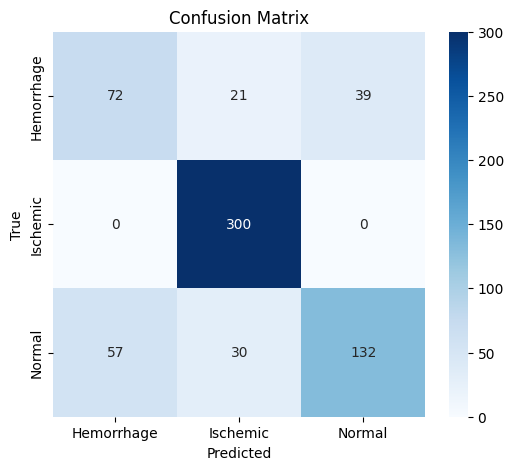

In [139]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import seaborn as sns
import matplotlib.pyplot as plt

tf.keras.backend.clear_session()

IMG_SIZE = 224
NUM_CLASSES = 3

# ====================================
# حساب class weights من generator
# ====================================

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(weights))

print("Class Weights:", class_weights)

# ====================================
# EfficientNet Backbone
# ====================================

base_model = tf.keras.applications.EfficientNetB0(

    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)

)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)

outputs = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=outputs)

# ====================================
# Compile Phase 1
# ====================================

model.compile(

    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]

)

model.summary()

# ====================================
# Callbacks
# ====================================

checkpoint = ModelCheckpoint(

    "best_efficientnet.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"

)

callbacks = [

    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3),
    checkpoint

]

# ====================================
# Phase 1 Training
# ====================================

print("===== Phase 1 Training =====")

history1 = model.fit(

    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks

)

# ====================================
# Phase 2 Fine Tuning
# ====================================

print("===== Phase 2 Fine Tuning =====")

model.load_weights("best_efficientnet.keras")

base_model.trainable = True

# فتح آخر 30 طبقة
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(

    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]

)

history2 = model.fit(

    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=[

        EarlyStopping(patience=5, restore_best_weights=True),
        ReduceLROnPlateau(patience=3)

    ]

)

# ====================================
# Evaluation
# ====================================

print("===== Final Evaluation =====")

pred = model.predict(test_generator)

pred_classes = np.argmax(pred, axis=1)

true_classes = test_generator.classes

class_names = list(test_generator.class_indices.keys())

print("\nAccuracy:", np.mean(pred_classes == true_classes))

print("\nClassification Report:\n")

print(classification_report(true_classes, pred_classes, target_names=class_names))

# ====================================
# Confusion Matrix
# ====================================

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names

)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()

# **DenseNet121**

In [141]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

tf.keras.backend.clear_session()

IMG_SIZE = 224
NUM_CLASSES = 3

# class weights
weights = compute_class_weight(
    "balanced",
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(weights))

# DenseNet
base_model = tf.keras.applications.DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)

outputs = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer=Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    EarlyStopping(patience=6, restore_best_weights=True),
    ReduceLROnPlateau(patience=3)
]

print("Training DenseNet121...")

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training DenseNet121...
Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 131s 637ms/step - accuracy: 0.3334 - loss: 1.6931 - val_accuracy: 0.6831 - val_loss: 0.7784 - learning_rate: 1.0000e-04
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 70s 427ms/step - accuracy: 0.5360 - loss: 1.1175 - val_accuracy: 0.8292 - val_loss: 0.5286 - learning_rate: 1.0000e-04
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 70s 427ms/step - accuracy: 0.6673 - loss: 0.8302 - val_accuracy: 0.8554 - val_loss: 0.4291 - learning_rate: 1.0000e-04
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 70s 427ms/step - accuracy: 0.7326 - loss: 0.7005 - val_accuracy: 0.8585 - val_loss: 0.3800 - learning_rate: 1.0000e-04
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 438ms/step - accuracy: 0.7603 - loss: 0.6329 - val_accuracy: 0.8662 - val_loss: 0.3436 - learning_rate: 1.0000e-04
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 434ms/step - accuracy: 0.7853 - loss: 0.5878 - val_accuracy: 0.8662 - val_loss: 0.315

In [142]:
from sklearn.metrics import classification_report
import numpy as np

pred = model.predict(test_generator)

pred_classes = np.argmax(pred, axis=1)

true_classes = test_generator.classes

print(classification_report(true_classes, pred_classes))

21/21 ━━━━━━━━━━━━━━━━━━━━ 26s 757ms/step
              precision    recall  f1-score   support

           0       0.72      0.82      0.76       132
           1       1.00      0.99      1.00       300
           2       0.87      0.80      0.84       219

    accuracy                           0.89       651
   macro avg       0.86      0.87      0.87       651
weighted avg       0.90      0.89      0.90       651



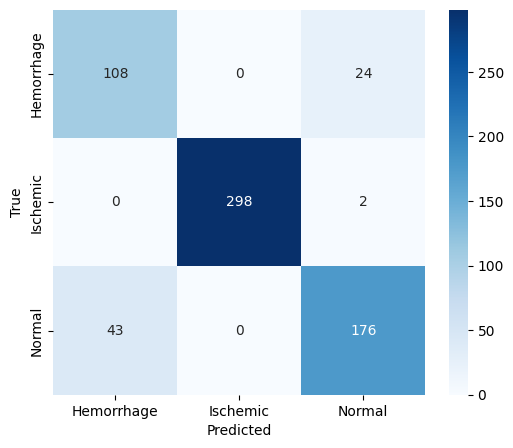

In [143]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=test_generator.class_indices,
    yticklabels=test_generator.class_indices
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

# **EfficientNetB4**

In [144]:
base_model = tf.keras.applications.EfficientNetB4(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)

outputs = Dense(3, activation="softmax")(x)

model = Model(base_model.input, outputs)

model.compile(
    optimizer=Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks
)

71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20


2026-03-07 02:04:02.261812: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-07 02:04:02.401481: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-07 02:04:02.712313: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-07 02:04:02.862081: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-07 02:04:03.288271: E external/local_xla/xla/stream_

 45/163 ━━━━━━━━━━━━━━━━━━━━ 48s 408ms/step - accuracy: 0.5086 - loss: 1.0774

2026-03-07 02:04:46.765025: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-07 02:04:46.899980: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-07 02:04:47.153542: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-07 02:04:47.300253: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-07 02:04:47.663112: E external/local_xla/xla/stream_

163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 562ms/step - accuracy: 0.5205 - loss: 1.0365

2026-03-07 02:06:08.102483: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-07 02:06:08.236495: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-07 02:06:08.476054: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-07 02:06:08.618428: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-07 02:06:08.960227: E external/local_xla/xla/stream_

163/163 ━━━━━━━━━━━━━━━━━━━━ 164s 729ms/step - accuracy: 0.5207 - loss: 1.0363 - val_accuracy: 0.6892 - val_loss: 0.8655 - learning_rate: 1.0000e-04
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 70s 427ms/step - accuracy: 0.6271 - loss: 0.9225 - val_accuracy: 0.7185 - val_loss: 0.7753 - learning_rate: 1.0000e-04
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 69s 424ms/step - accuracy: 0.6646 - loss: 0.8603 - val_accuracy: 0.7200 - val_loss: 0.7400 - learning_rate: 1.0000e-04
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 69s 425ms/step - accuracy: 0.6675 - loss: 0.8648 - val_accuracy: 0.7154 - val_loss: 0.6717 - learning_rate: 1.0000e-04
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 69s 422ms/step - accuracy: 0.6907 - loss: 0.8094 - val_accuracy: 0.7385 - val_loss: 0.6576 - learning_rate: 1.0000e-04
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 69s 422ms/step - accuracy: 0.6770 - loss: 0.8064 - val_accuracy: 0.7569 - val_loss: 0.6476 - learning_rate: 1.0000e-04
Epoch 7/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 69s 420ms/step -

In [145]:
from sklearn.metrics import classification_report
import numpy as np

pred = model.predict(test_generator)

pred_classes = np.argmax(pred, axis=1)

true_classes = test_generator.classes

print(classification_report(true_classes, pred_classes))

20/21 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step

2026-03-07 02:28:37.324402: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-07 02:28:37.458570: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-07 02:28:37.703781: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-07 02:28:37.848200: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-07 02:28:38.197366: E external/local_xla/xla/stream_

21/21 ━━━━━━━━━━━━━━━━━━━━ 30s 977ms/step
              precision    recall  f1-score   support

           0       0.54      0.64      0.59       132
           1       0.97      1.00      0.98       300
           2       0.74      0.64      0.69       219

    accuracy                           0.80       651
   macro avg       0.75      0.76      0.75       651
weighted avg       0.81      0.80      0.80       651



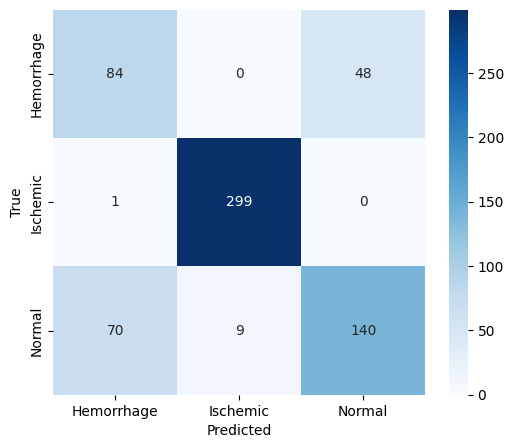

In [146]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=test_generator.class_indices,
    yticklabels=test_generator.class_indices
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

# **ResNet50**

In [152]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

IMG_SIZE = 224

tf.keras.backend.clear_session()

# =========================
# Base Model
# =========================

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

# =========================
# Custom Head
# =========================

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(512, activation="relu")(x)
x = Dropout(0.5)(x)

outputs = Dense(3, activation="softmax")(x)

resnet_model = Model(inputs=base_model.input, outputs=outputs)

# =========================
# Compile
# =========================

resnet_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

resnet_model.summary()

# =========================
# Callbacks
# =========================

callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-6
    ),

    ModelCheckpoint(
        "resnet_model.keras",
        monitor="val_accuracy",
        save_best_only=True
    )

]

# =========================
# Phase 1 Training
# =========================

print("===== Phase 1 Training =====")

history_resnet = resnet_model.fit(

    train_generator,

    validation_data=val_generator,

    epochs=20,

    class_weight=class_weights,

    callbacks=callbacks

)

# =========================
# Fine Tuning
# =========================

print("===== Fine Tuning =====")

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

resnet_model.compile(

    optimizer=Adam(learning_rate=1e-5),

    loss="categorical_crossentropy",

    metrics=["accuracy"]

)

history_resnet_finetune = resnet_model.fit(

    train_generator,

    validation_data=val_generator,

    epochs=10,

    class_weight=class_weights,

    callbacks=callbacks

)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,638,339 (93.99 MB)

 Trainable params: 1,050,627 (4.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

===== Phase 1 Training =====
Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 96s 524ms/step - accuracy: 0.5640 - loss: 0.9688 - val_accuracy: 0.8508 - val_loss: 0.3727 - learning_rate: 1.0000e-04
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 432ms/step - accuracy: 0.7941 - loss: 0.5381 - val_accuracy: 0.8631 - val_loss: 0.3373 - learning_rate: 1.0000e-04
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 70s 428ms/step - accuracy: 0.8120 - loss: 0.4716 - val_accuracy: 0.8431 - val_loss: 0.3413 - learning_rate: 1.0000e-04
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 70s 427ms/step - accuracy: 0.8243 - loss: 0.4260 - val_accuracy: 0.8385 - val_loss: 0.3225 - learning_rate: 1.0000e-04
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 70s 428ms/step - accuracy: 0.8332 - loss: 0.4118 - val_accuracy: 0.8446 - val_loss: 0.3148 - learning_rate: 1.0000e-04
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 70s 427ms/step - accuracy: 0.8400 - loss: 0.3894 - val_accuracy: 0.8615 - val_loss: 0.2932 - learning_rate: 1.0000e-04
Epoch 7/20
163/16

In [153]:
from sklearn.metrics import classification_report, accuracy_score, f1_score
import numpy as np

pred = resnet_model.predict(test_generator)

pred_classes = np.argmax(pred, axis=1)

true_classes = test_generator.classes

print("Accuracy:", accuracy_score(true_classes, pred_classes))

print("F1 Score:", f1_score(true_classes, pred_classes, average="macro"))

print("\nClassification Report\n")

print(classification_report(true_classes, pred_classes))

21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 270ms/step
Accuracy: 0.9508448540706606
F1 Score: 0.9365963301055883

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.92      0.88       132
           1       1.00      1.00      1.00       300
           2       0.95      0.90      0.93       219

    accuracy                           0.95       651
   macro avg       0.93      0.94      0.94       651
weighted avg       0.95      0.95      0.95       651



In [154]:
from sklearn.metrics import classification_report, accuracy_score, f1_score
import numpy as np

pred = resnet_model.predict(test_generator)

pred_classes = np.argmax(pred, axis=1)

true_classes = test_generator.classes

print("Accuracy:", accuracy_score(true_classes, pred_classes))

print("F1 Score:", f1_score(true_classes, pred_classes, average="macro"))

print("\nClassification Report\n")

print(classification_report(true_classes, pred_classes))

21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step
Accuracy: 0.9508448540706606
F1 Score: 0.9365963301055883

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.92      0.88       132
           1       1.00      1.00      1.00       300
           2       0.95      0.90      0.93       219

    accuracy                           0.95       651
   macro avg       0.93      0.94      0.94       651
weighted avg       0.95      0.95      0.95       651



# **Hybrid CNN (ResNet + DenseNet)**

In [162]:
import tensorflow as tf
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout, concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

IMG_SIZE = 224
NUM_CLASSES = 3

# ======================
# Input
# ======================

input_layer = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# ======================
# ResNet branch
# ======================

resnet_base = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

resnet_base.trainable = False

resnet_features = resnet_base(input_layer)

resnet_features = GlobalAveragePooling2D()(resnet_features)

# ======================
# DenseNet branch
# ======================

densenet_base = tf.keras.applications.DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

densenet_base.trainable = False

densenet_features = densenet_base(input_layer)

densenet_features = GlobalAveragePooling2D()(densenet_features)

# ======================
# Feature Fusion
# ======================

merged = concatenate([resnet_features, densenet_features])

x = Dense(512, activation="relu")(merged)
x = Dropout(0.5)(x)

x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)

output = Dense(NUM_CLASSES, activation="softmax")(x)

# ======================
# Final Model
# ======================

hybrid_model = Model(inputs=input_layer, outputs=output)

hybrid_model.summary()

# ======================
# Compile
# ======================

hybrid_model.compile(
    optimizer=Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ======================
# Callbacks
# ======================

callbacks = [
    EarlyStopping(patience=6, restore_best_weights=True),
    ReduceLROnPlateau(patience=3)
]

# ======================
# Training
# ======================

history = hybrid_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks
)

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ input_layer_3[0]… │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet121         │ (None, 7, 7,      │  7,037,504 │ input_layer_3[0]… │
│ (Functional)        │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1024)      │          0 │ densenet121[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 3072)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 512)       │  1,573,376 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 512)       │          0 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 128)       │     65,664 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 128)       │          0 │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 3)         │        387 │ dropout_6[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 32,264,643 (123.08 MB)

 Trainable params: 1,639,427 (6.25 MB)

 Non-trainable params: 30,625,216 (116.83 MB)

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 142s 684ms/step - accuracy: 0.6439 - loss: 0.8378 - val_accuracy: 0.8785 - val_loss: 0.2619 - learning_rate: 1.0000e-04
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 74s 452ms/step - accuracy: 0.8474 - loss: 0.3871 - val_accuracy: 0.8892 - val_loss: 0.2335 - learning_rate: 1.0000e-04
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 74s 453ms/step - accuracy: 0.8599 - loss: 0.3508 - val_accuracy: 0.9108 - val_loss: 0.1958 - learning_rate: 1.0000e-04
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 74s 452ms/step - accuracy: 0.8810 - loss: 0.3144 - val_accuracy: 0.9200 - val_loss: 0.1891 - learning_rate: 1.0000e-04
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 74s 453ms/step - accuracy: 0.8817 - loss: 0.2990 - val_accuracy: 0.9185 - val_loss: 0.1751 - learning_rate: 1.0000e-04
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 73s 447ms/step - accuracy: 0.8882 - loss: 0.2901 - val_accuracy: 0.9292 - val_loss: 0.1650 - learning_rate: 1.0000e-04
Epoch 7/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 72s 4

In [163]:
from sklearn.metrics import classification_report
import numpy as np

pred = model.predict(test_generator)

pred_classes = np.argmax(pred, axis=1)
true_classes = test_generator.classes

print(classification_report(true_classes, pred_classes))

21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 134ms/step
              precision    recall  f1-score   support

           0       0.54      0.64      0.59       132
           1       0.97      1.00      0.98       300
           2       0.74      0.64      0.69       219

    accuracy                           0.80       651
   macro avg       0.75      0.76      0.75       651
weighted avg       0.81      0.80      0.80       651



# **Hybrid CNN + SE Attention**

In [164]:
import tensorflow as tf
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout, concatenate, Reshape, Multiply
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

IMG_SIZE = 224
NUM_CLASSES = 3

# ======================
# SE Attention Block
# ======================

def se_block(input_tensor, ratio=16):

    channels = input_tensor.shape[-1]

    se = GlobalAveragePooling2D()(input_tensor)
    se = Reshape((1,1,channels))(se)

    se = Dense(channels // ratio, activation="relu")(se)
    se = Dense(channels, activation="sigmoid")(se)

    x = Multiply()([input_tensor, se])

    return x

# ======================
# Input
# ======================

input_layer = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# ======================
# ResNet Branch
# ======================

resnet_base = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

resnet_base._name = "resnet_branch"

resnet_base.trainable = False

resnet_out = resnet_base(input_layer)

resnet_out = se_block(resnet_out)

resnet_features = GlobalAveragePooling2D()(resnet_out)

# ======================
# DenseNet Branch
# ======================

densenet_base = tf.keras.applications.DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

densenet_base._name = "densenet_branch"

densenet_base.trainable = False

densenet_out = densenet_base(input_layer)

densenet_out = se_block(densenet_out)

densenet_features = GlobalAveragePooling2D()(densenet_out)

# ======================
# Feature Fusion
# ======================

merged = concatenate([resnet_features, densenet_features])

x = Dense(512, activation="relu")(merged)
x = Dropout(0.5)(x)

x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)

output = Dense(NUM_CLASSES, activation="softmax")(x)

# ======================
# Final Model
# ======================

hybrid_model = Model(inputs=input_layer, outputs=output)

hybrid_model.summary()

# ======================
# Compile
# ======================

hybrid_model.compile(
    optimizer=Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ======================
# Callbacks
# ======================

callbacks = [
    EarlyStopping(patience=6, restore_best_weights=True),
    ReduceLROnPlateau(patience=3)
]

# ======================
# Training
# ======================

history = hybrid_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks
)

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ input_layer_6[0]… │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet121         │ (None, 7, 7,      │  7,037,504 │ input_layer_6[0]… │
│ (Functional)        │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1024)      │          0 │ densenet121[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 1, 1,      │          0 │ global_average_p… │
│                     │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 1, 1,      │          0 │ global_average_p… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 1, 1, 128) │    262,272 │ reshape_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 1, 1, 64)  │     65,600 │ reshape_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 1, 1,      │    264,192 │ dense_15[0][0]    │
│                     │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 1, 1,      │     66,560 │ dense_17[0][0]    │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_2          │ (None, 7, 7,      │          0 │ resnet50[0][0],   │
│ (Multiply)          │ 2048)             │            │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_3          │ (None, 7, 7,      │          0 │ densenet121[0][0… │
│ (Multiply)          │ 1024)             │            │ dense_18[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ multiply_2[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1024)      │          0 │ multiply_3[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 3072)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 512)       │  1,573,376 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 512)       │          0 │ dense_19[0][0]  

 Total params: 32,923,267 (125.59 MB)

 Trainable params: 2,298,051 (8.77 MB)

 Non-trainable params: 30,625,216 (116.83 MB)

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 145s 677ms/step - accuracy: 0.6776 - loss: 0.7548 - val_accuracy: 0.8646 - val_loss: 0.2757 - learning_rate: 1.0000e-04
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 74s 450ms/step - accuracy: 0.8571 - loss: 0.3694 - val_accuracy: 0.9015 - val_loss: 0.2204 - learning_rate: 1.0000e-04
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 72s 438ms/step - accuracy: 0.8740 - loss: 0.3187 - val_accuracy: 0.9046 - val_loss: 0.1997 - learning_rate: 1.0000e-04
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 433ms/step - accuracy: 0.8931 - loss: 0.2787 - val_accuracy: 0.9169 - val_loss: 0.1856 - learning_rate: 1.0000e-04
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 72s 443ms/step - accuracy: 0.8957 - loss: 0.2768 - val_accuracy: 0.9200 - val_loss: 0.1702 - learning_rate: 1.0000e-04
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 437ms/step - accuracy: 0.9084 - loss: 0.2483 - val_accuracy: 0.9154 - val_loss: 0.1683 - learning_rate: 1.0000e-04
Epoch 7/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 75s 4

In [165]:
from sklearn.metrics import classification_report
import numpy as np

pred = model.predict(test_generator)

pred_classes = np.argmax(pred, axis=1)

true_classes = test_generator.classes

print(classification_report(true_classes, pred_classes))

21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step
              precision    recall  f1-score   support

           0       0.54      0.64      0.59       132
           1       0.97      1.00      0.98       300
           2       0.74      0.64      0.69       219

    accuracy                           0.80       651
   macro avg       0.75      0.76      0.75       651
weighted avg       0.81      0.80      0.80       651



In [166]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    roc_curve,
    auc
)

# ==========================
# Predictions
# ==========================
pred = model.predict(test_generator)
pred_classes = np.argmax(pred, axis=1)
true_classes = test_generator.classes
class_names = list(test_generator.class_indices.keys())

21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step


# Metrics

In [167]:
print("Accuracy:", accuracy_score(true_classes, pred_classes))
print("F1 Score:", f1_score(true_classes, pred_classes, average="macro"))
print("\nClassification Report\n")
print(classification_report(true_classes, pred_classes, target_names=class_names))

Accuracy: 0.8033794162826421
F1 Score: 0.7522930577327239

Classification Report

              precision    recall  f1-score   support

  Hemorrhage       0.54      0.64      0.59       132
    Ischemic       0.97      1.00      0.98       300
      Normal       0.74      0.64      0.69       219

    accuracy                           0.80       651
   macro avg       0.75      0.76      0.75       651
weighted avg       0.81      0.80      0.80       651



# Confusion Matrix

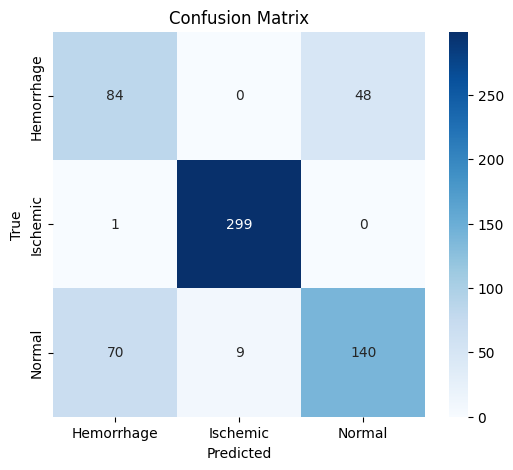

In [168]:
cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

# Training Curves

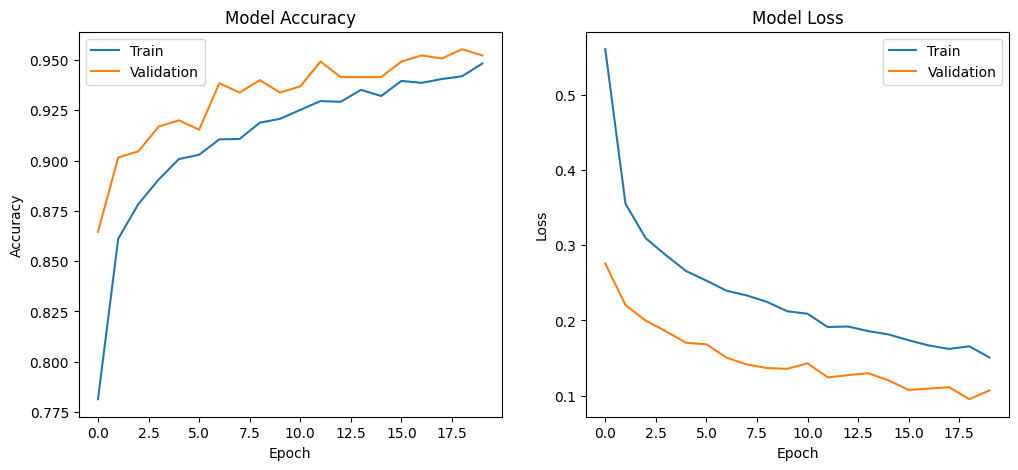

In [169]:
plt.figure(figsize=(12,5))
# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
# Loss
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig("training_curves.png", dpi=300)
plt.show()

# Confusion Matrix Percentage


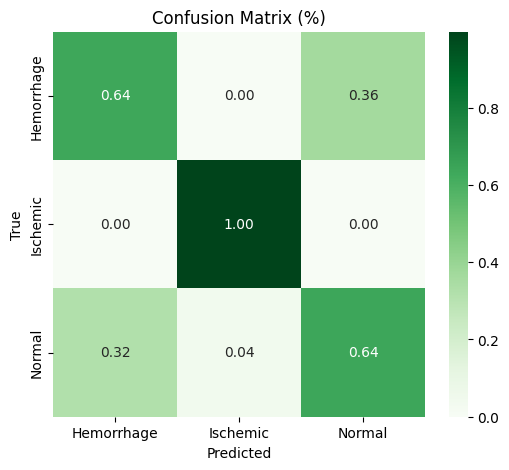

In [170]:
cm_percent = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(6,5))
sns.heatmap(
    cm_percent,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix (%)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig("confusion_matrix_percent.png", dpi=300)
plt.show()

# ROC Curve

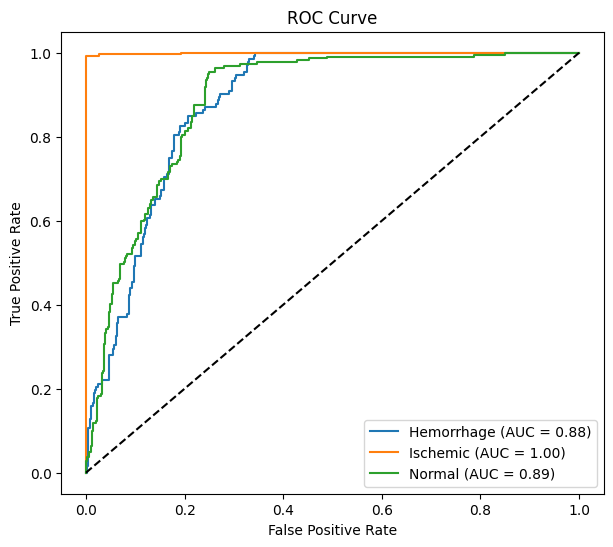

In [171]:
from sklearn.preprocessing import label_binarize
true_binary = label_binarize(true_classes, classes=[0,1,2])
plt.figure(figsize=(7,6))
for i in range(len(class_names)):
    fpr, tpr, _ = roc_curve(true_binary[:,i], pred[:,i])
    roc_auc = auc(fpr, tpr)
    plt.plot(
        fpr,
        tpr,
        label=f"{class_names[i]} (AUC = {roc_auc:.2f})"
    )
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig("roc_curve.png", dpi=300)
plt.show()

# **Vision Transformer (ViT)**

In [172]:
!pip install vit-keras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 3.2 MB/s eta 0:00:00


In [183]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model

IMG_SIZE = 224
PATCH_SIZE = 16
NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2
PROJECTION_DIM = 64
NUM_HEADS = 4
TRANSFORMER_LAYERS = 8
MLP_UNITS = [128, 64]
NUM_CLASSES = 3

In [184]:
class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size
    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

In [185]:
class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches,
            output_dim=projection_dim,
        )
    def call(self, patch):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.projection(patch) + self.position_embedding(positions)
        return encoded

In [186]:
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
patches = Patches(PATCH_SIZE)(inputs)
encoded_patches = PatchEncoder(NUM_PATCHES, PROJECTION_DIM)(patches)
for _ in range(TRANSFORMER_LAYERS):
    x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    attention_output = layers.MultiHeadAttention(
        num_heads=NUM_HEADS,
        key_dim=PROJECTION_DIM
    )(x1, x1)
    x2 = layers.Add()([attention_output, encoded_patches])
    x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
    x3 = layers.Dense(MLP_UNITS[0], activation="relu")(x3)
    x3 = layers.Dense(PROJECTION_DIM)(x3)
    encoded_patches = layers.Add()([x3, x2])
representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
representation = layers.Flatten()(representation)
representation = layers.Dropout(0.5)(representation)
features = layers.Dense(256, activation="relu")(representation)
features = layers.Dropout(0.5)(features)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(features)
vit_model = Model(inputs=inputs, outputs=outputs)
vit_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches (Patches)   │ (None, None, 768) │          0 │ input_layer_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder       │ (None, 196, 64)   │     61,760 │ patches[0][0]     │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 196, 64)   │        128 │ patch_encoder[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 196, 64)   │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 196, 64)   │          0 │ multi_head_atten… │
│                     │                   │            │ patch_encoder[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 196, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 196, 64)   │      8,256 │ dense_23[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 196, 64)   │          0 │ dense_24[0][0],   │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 196, 64)   │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 196, 64)   │          0 │ multi_head_atten… │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 196, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 196, 64)   │      8,256 │ dense_25[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 196, 64)   │          0 │ dense_26[0][0],   │
│                     │                   │            │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 3,939,779 (15.03 MB)

 Trainable params: 3,939,779 (15.03 MB)

 Non-trainable params: 0 (0.00 B)

In [187]:
vit_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]

)

In [188]:
history_vit = vit_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights
)

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 117s 539ms/step - accuracy: 0.6172 - loss: 1.1248 - val_accuracy: 0.7708 - val_loss: 0.3848
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 437ms/step - accuracy: 0.7724 - loss: 0.5222 - val_accuracy: 0.8031 - val_loss: 0.3948
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 434ms/step - accuracy: 0.8011 - loss: 0.4728 - val_accuracy: 0.8062 - val_loss: 0.3387
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 436ms/step - accuracy: 0.8096 - loss: 0.4378 - val_accuracy: 0.8077 - val_loss: 0.3195
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 72s 441ms/step - accuracy: 0.8314 - loss: 0.3778 - val_accuracy: 0.8092 - val_loss: 0.3086
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 72s 440ms/step - accuracy: 0.8331 - loss: 0.3958 - val_accuracy: 0.8323 - val_loss: 0.2840
Epoch 7/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 435ms/step - accuracy: 0.8389 - loss: 0.3762 - val_accuracy: 0.8246 - val_loss: 0.2922
Epoch 8/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 436ms/step - accuracy: 0.8411 - loss: 

In [193]:
pred = vit_model.predict(test_generator)
pred_classes = pred.argmax(axis=1)
true_classes = test_generator.classes
print(classification_report(true_classes, pred_classes))

21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step
              precision    recall  f1-score   support

           0       0.68      0.79      0.73       132
           1       1.00      1.00      1.00       300
           2       0.86      0.78      0.82       219

    accuracy                           0.88       651
   macro avg       0.85      0.86      0.85       651
weighted avg       0.89      0.88      0.88       651



# **Grad-CAM**

In [217]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd

In [226]:
img_path = test_df.iloc[3]["image_path"]

print("Image:", img_path)

Image: /kaggle/input/datasets/vbookshelf/computed-tomography-ct-images/computed-tomography-images-for-intracranial-hemorrhage-detection-and-segmentation-1.0.0/Patients_CT/074/brain/10.jpg


In [227]:
IMG_SIZE = 224

def preprocess_image(img_path):

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    img_array = img / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    return img, img_array

In [228]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)

        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0) / np.max(heatmap)

    return heatmap

In [229]:
def overlay_heatmap(heatmap, image):

    heatmap = cv2.resize(heatmap, (image.shape[1], image.shape[0]))

    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = cv2.addWeighted(image, 0.7, heatmap, 0.3, 0)

    return superimposed_img

In [230]:
img, img_array = preprocess_image(img_path)

heatmap = make_gradcam_heatmap(
    img_array,
    resnet_model,
    "conv5_block3_out"
)

result = overlay_heatmap(heatmap, img)

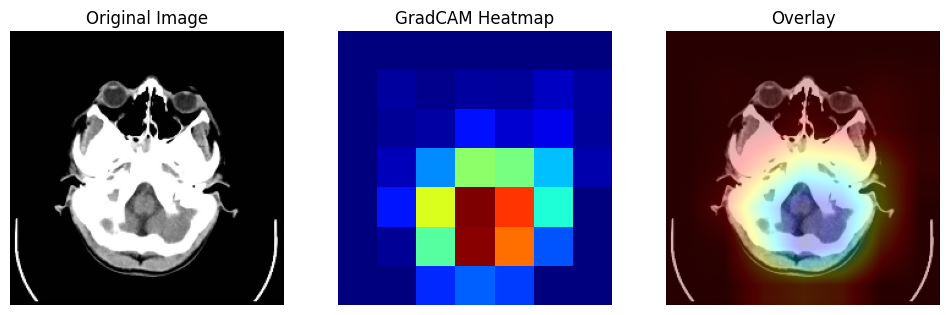

In [231]:
plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(heatmap, cmap="jet")
plt.title("GradCAM Heatmap")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(result)
plt.title("Overlay")
plt.axis("off")

plt.show()

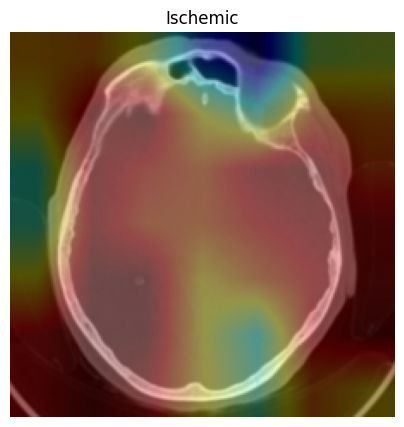

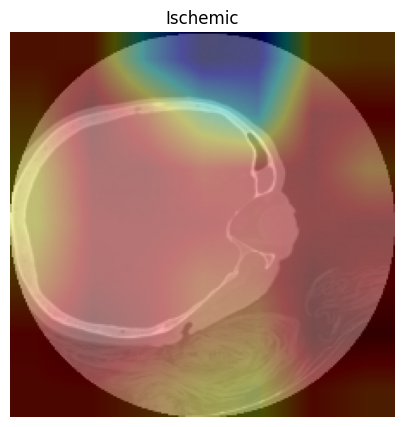

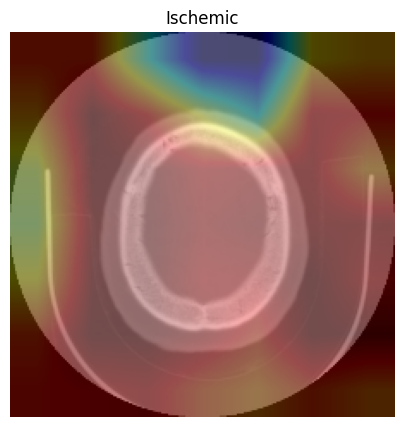

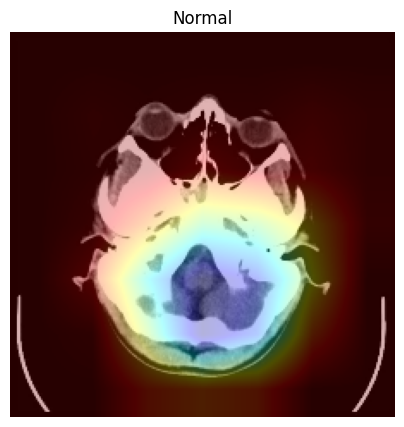

In [ ]:
for i in range(5):

    img_path = test_df.iloc[i]["image_path"]

    img, img_array = preprocess_image(img_path)

    heatmap = make_gradcam_heatmap(
        img_array,
        resnet_model,
        "conv5_block3_out"
    )

    result = overlay_heatmap(heatmap, img)

    plt.figure(figsize=(5,5))
    plt.imshow(result)
    plt.title(test_df.iloc[i]["label"])
    plt.axis("off")
    plt.show()

In [234]:
import matplotlib.pyplot as plt
import numpy as np

models = ["ResNet50", "DenseNet121", "EfficientNetB4"]

accuracy = [
    resnet_accuracy,
    densenet_accuracy,
    efficientnet_accuracy
]

f1_scores = [
    resnet_f1,
    densenet_f1,
    efficientnet_f1
]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, accuracy, width, label="Accuracy")
plt.bar(x + width/2, f1_scores, width, label="F1 Score")

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("Model Performance Comparison")

plt.legend()

plt.show()

NameError: name 'resnet_accuracy' is not defined

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_true = test_generator.classes

y_true_bin = label_binarize(y_true, classes=[0,1,2])

# predictions
pred_resnet = resnet_model.predict(test_generator)
pred_densenet = densenet_model.predict(test_generator)
pred_efficient = efficientnet_model.predict(test_generator)

plt.figure(figsize=(7,6))

for name, pred in zip(
    ["ResNet50","DenseNet121","EfficientNetB4"],
    [pred_resnet,pred_densenet,pred_efficient]
):

    fpr, tpr, _ = roc_curve(
        y_true_bin.ravel(),
        pred.ravel()
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} AUC = {roc_auc:.3f}")

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()

In [233]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

pred_classes = np.argmax(pred_resnet, axis=1)

cm = confusion_matrix(y_true, pred_classes)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Hemorrhage","Ischemic","Normal"],
    yticklabels=["Hemorrhage","Ischemic","Normal"]
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.title("Confusion Matrix (ResNet50)")

plt.show()

NameError: name 'pred_resnet' is not defined